In [210]:
!pip -q install graphviz

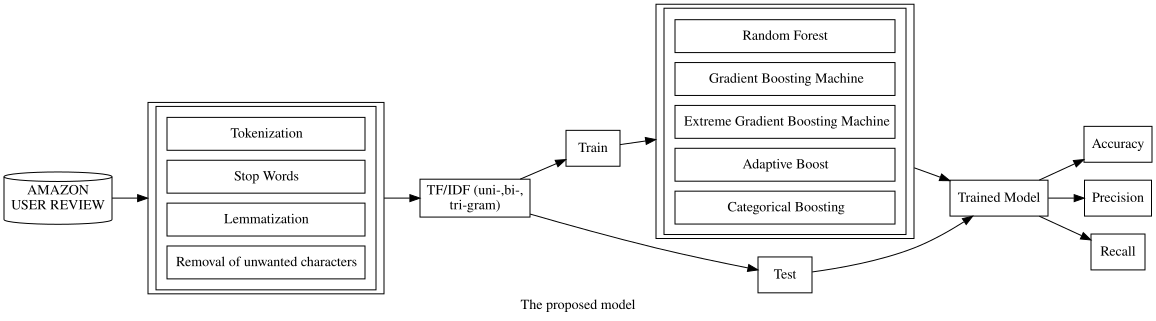

In [211]:
from graphviz import Digraph

dot = Digraph(comment='The proposed system')
dot.attr(rankdir='LR',label='The proposed model')

# Nodes
dot.node('A', 'AMAZON\nUSER REVIEW', shape='cylinder')
# with dot.subgraph(name='cluster_0') as c:
#         c.node_attr.update(style='filled', shape='box',color='white')
#         c.node('a0', 'Removal of\nunwanted\ncharacters')
#         c.node('a1', 'Lemmitization')
#         c.node('a2', 'Stop word')
#         c.node('a3', 'Tokenization')
#         c.attr(label='Process #1')
dot.node("B", label='''<
<TABLE BORDER="1" CELLBORDER="1" CELLSPACING="10" CELLPADDING="8">
  <TR><TD>Tokenization</TD></TR>
  <TR><TD>Stop Words</TD></TR>
  <TR><TD>Lemmatization</TD></TR>
  <TR><TD>Removal of unwanted characters</TD></TR>
</TABLE>
>''', shape='box')

dot.node('C',"TF/IDF (uni-,bi-,\ntri-gram)",shape='box')
dot.node('D','Train',shape='box')
dot.node('E','Test',shape='box')


dot.node("F", label='''<
<TABLE BORDER="1" CELLBORDER="1" CELLSPACING="10" CELLPADDING="8">
  <TR><TD>Random Forest</TD></TR>
  <TR><TD>Gradient Boosting Machine</TD></TR>
  <TR><TD>Extreme Gradient Boosting Machine</TD></TR>
  <TR><TD>Adaptive Boost</TD></TR>
  <TR><TD>Categorical Boosting</TD></TR>
</TABLE>
>''', shape='box')
dot.node('G','Trained Model',shape='box')
dot.node('H','Accuracy',shape='box')
dot.node('I','Precision',shape='box')
dot.node('J','Recall',shape='box')
dot.edges([('A','B'),('B','C'),('C','D'),('C','E'),('D','F'), ('E','G'),('F','G'), ('G','H'),('G','I'),('G','J')])
dot.render('proposed_system', view=True)
dot

## Step 1 (Installing/importing important modules)
- `nltk` $→$ For the tokenization,stopwords, lemmatization and removal of unwanted characters.
- `pandas` $→$ For data cleaning and manipulation.
- `matplotlib` $→$ For visualization.
- `scikit-learn` $→$ For transforming/splitting data, for using machine learning models.

In [212]:
!pip install -q nltk pandas matplotlib scikit-learn catboost

In [259]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from time import time

# NLP tools
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# ML tools
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score, KFold, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score, roc_curve, auc
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from imblearn.over_sampling import SMOTE
import warnings
import pickle


In [214]:

# Suppress warnings
warnings.filterwarnings('ignore')

# Download necessary NLTK data
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

# Set plot style
plt.style.use('fivethirtyeight')


In [215]:

# Step 1: Load and examine the data
print("Loading data...")
df = pd.read_excel('DATASET.xlsx')
print(f"Dataset shape: {df.shape}")

# Select only relevant columns
df = df[['review_rating', 'review_text']]
df.head()


Loading data...
Dataset shape: (500, 6)


,review_rating,review_text
0,4,I remember reading somewhere that Haruki Murak...
1,5,If I had to sum this book up with one sentence...
2,5,I embarked on a list of '100 books to read bef...
3,5,"The fiction, the fame and the personality of H..."
4,4,"4.5 stars, rounded to 4The stories are complet..."


In [216]:

# Check for missing values
print("\nChecking for missing values:")
print(df.isna().sum())



Checking for missing values:
review_rating    0
review_text      0
dtype: int64


In [217]:

# Analyze rating distribution
ratings_count = df.review_rating.value_counts().sort_index()
print("\nRating distribution:")
print(ratings_count)



Rating distribution:
review_rating
1     22
2     34
3     55
4     94
5    295
Name: count, dtype: int64


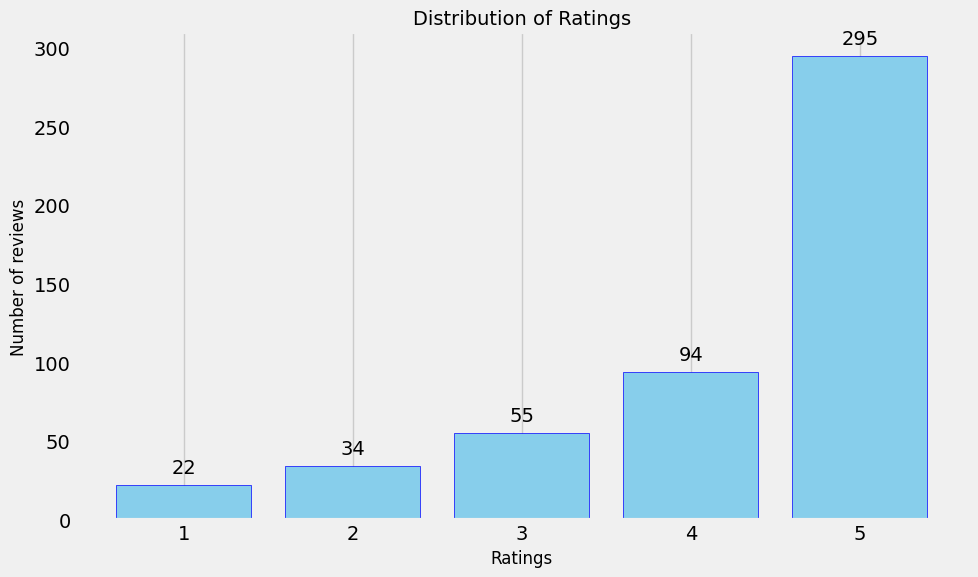

In [218]:

# Visualize rating distribution
plt.figure(figsize=(10, 6))
bars = plt.bar(ratings_count.index, ratings_count.values, color='skyblue', edgecolor='blue')
plt.xlabel('Ratings', fontsize=12)
plt.ylabel('Number of reviews', fontsize=12)
plt.title('Distribution of Ratings', fontsize=14)
plt.xticks(ratings_count.index)

# Add count labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 5,
             f'{height}', ha='center', va='bottom')
plt.grid(axis='y')
plt.tight_layout()
plt.savefig('rating_distribution.png')
plt.show()

In [219]:
# Step 2: Preprocess the text data
print("\nPreprocessing text data...")

def preprocess_text(text):
    """Apply all preprocessing steps"""
    if not isinstance(text, str):
        return ""

    # Normalization - Convert to lowercase
    text = text.lower()

    # Remove special characters and numbers
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\d+', '', text)

    # Tokenization
    tokens = word_tokenize(text)

    # Stop word removal
    stop_words = set(stopwords.words('english'))
    tokens = [token for token in tokens if token not in stop_words]

    # Lemmatization
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(token) for token in tokens]

    # Join tokens back into text
    processed_text = ' '.join(tokens)

    return processed_text



Preprocessing text data...


In [220]:

# Apply preprocessing
df['cleaned_text'] = df.review_text.apply(preprocess_text)
print("Sample of cleaned text:")
print(df[['review_text', 'cleaned_text']].head(2))

Sample of cleaned text:
                                         review_text  \
0  I remember reading somewhere that Haruki Murak...   
1  If I had to sum this book up with one sentence...   

                                        cleaned_text  
0  remember reading somewhere haruki murakamis bo...  
1  sum book one sentence id say thisnothing seems...  



Converting to binary sentiment classification...
sentiment
positive    389
negative    111
Name: count, dtype: int64
Positive: 77.8%, Negative: 22.2%


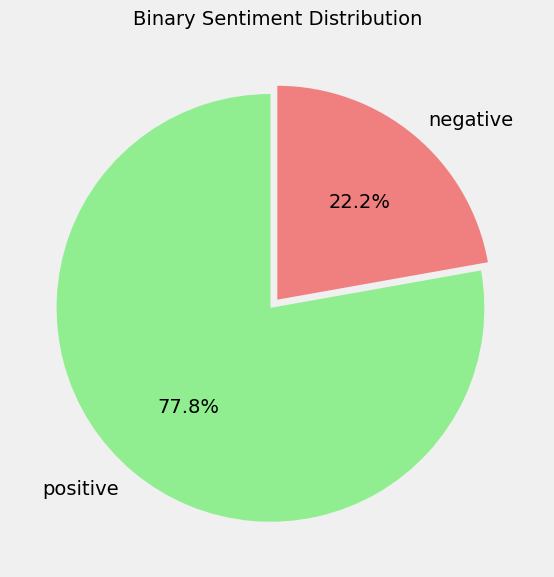

In [221]:
# Step 3: Convert to binary sentiment
print("\nConverting to binary sentiment classification...")
# Ratings 4-5 are positive, 1-3 are negative
df['sentiment'] = df.review_rating.apply(lambda x: 'positive' if x >= 4 else 'negative')
sentiment_count = df.sentiment.value_counts()
print(sentiment_count)

# Calculate percentages
sentiment_percent = sentiment_count / sentiment_count.sum() * 100
print(f"Positive: {sentiment_percent['positive']:.1f}%, Negative: {sentiment_percent['negative']:.1f}%")

# Visualize sentiment distribution
plt.figure(figsize=(8, 6))
plt.pie(sentiment_count.values, labels=sentiment_count.index, autopct='%1.1f%%',
        colors=['lightgreen', 'lightcoral'], startangle=90, explode=[0.05, 0])
plt.title('Binary Sentiment Distribution', fontsize=14)
plt.tight_layout()
plt.savefig('sentiment_distribution.png')
plt.show()

In [222]:
# Step 4: TF-IDF Feature Extraction
print("\nPerforming TF-IDF feature extraction...")

# Prepare data for modeling
X = df.cleaned_text
y = df.sentiment

# Split into training and testing sets (80:20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training set size: {len(X_train)}, Test set size: {len(X_test)}")

# Apply TF-IDF vectorization
tfidf_vectorizer = TfidfVectorizer(
    min_df=5,          # Minimum document frequency
    max_df=0.8,        # Maximum document frequency
    max_features=5000, # Maximum number of features
    ngram_range=(1, 3) # Use unigrams, bigrams, and trigrams
)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print(f"TF-IDF feature matrix shape: {X_train_tfidf.shape}")



Performing TF-IDF feature extraction...
Training set size: 400, Test set size: 100
TF-IDF feature matrix shape: (400, 574)


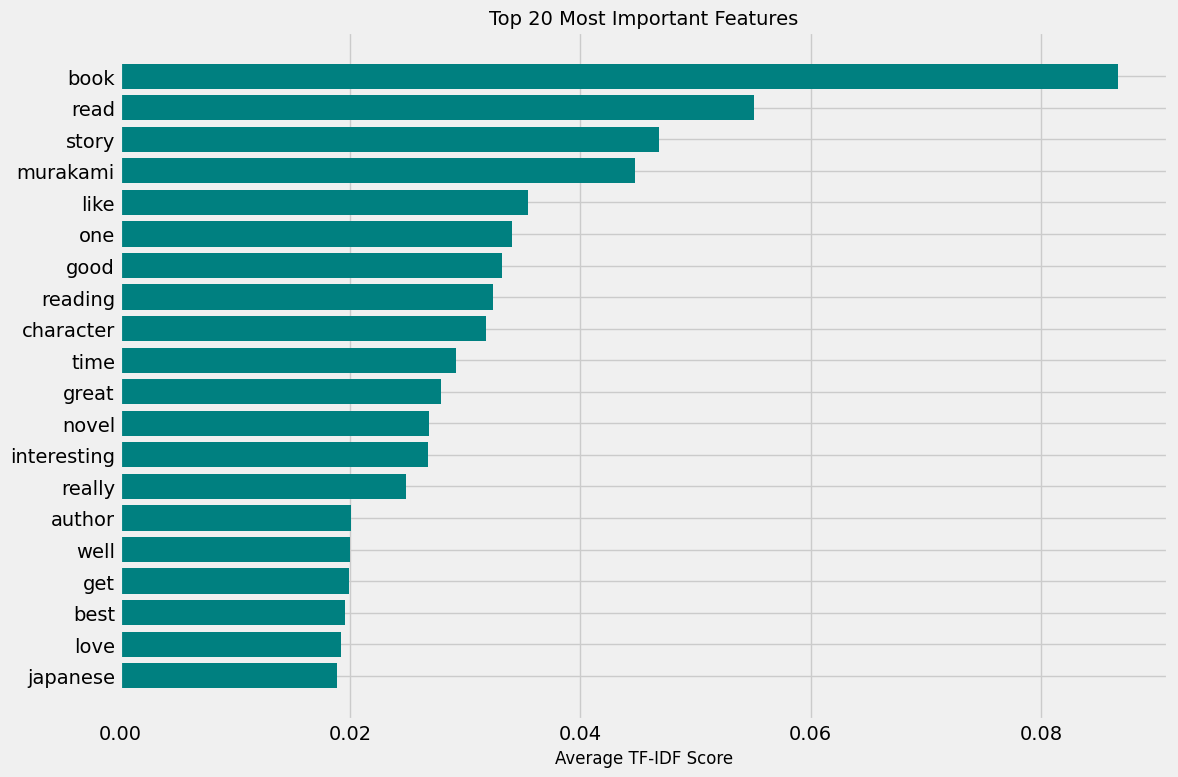

In [223]:

# Visualize top features
def plot_top_features(vectorizer, top_n=20):
    """Plot the top features based on their average TF-IDF score"""
    feature_names = vectorizer.get_feature_names_out()
    tfidf_mean = X_train_tfidf.mean(axis=0).A1

    # Get top features
    indices = np.argsort(tfidf_mean)[::-1][:top_n]
    top_features = [(feature_names[i], tfidf_mean[i]) for i in indices]

    # Plot
    plt.figure(figsize=(12, 8))
    plt.barh([x[0] for x in top_features][::-1], [x[1] for x in top_features][::-1], color='teal')
    plt.title(f'Top {top_n} Most Important Features', fontsize=14)
    plt.xlabel('Average TF-IDF Score', fontsize=12)
    plt.tight_layout()
    plt.savefig('top_features.png')
    plt.show()

plot_top_features(tfidf_vectorizer)

In [224]:
# Step 5: Handle class imbalance with SMOTE
print("\nHandling class imbalance with SMOTE...")
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_tfidf, y_train)
print(f"Before SMOTE - Training data shape: {X_train_tfidf.shape}")
print(f"Class distribution before SMOTE: {pd.Series(y_train).value_counts()}")
print(f"After SMOTE - Training data shape: {X_train_balanced.shape}")
print(f"Class distribution after SMOTE: {pd.Series(y_train_balanced).value_counts()}")



Handling class imbalance with SMOTE...
Before SMOTE - Training data shape: (400, 574)
Class distribution before SMOTE: sentiment
positive    311
negative     89
Name: count, dtype: int64
After SMOTE - Training data shape: (622, 574)
Class distribution after SMOTE: sentiment
negative    311
positive    311
Name: count, dtype: int64


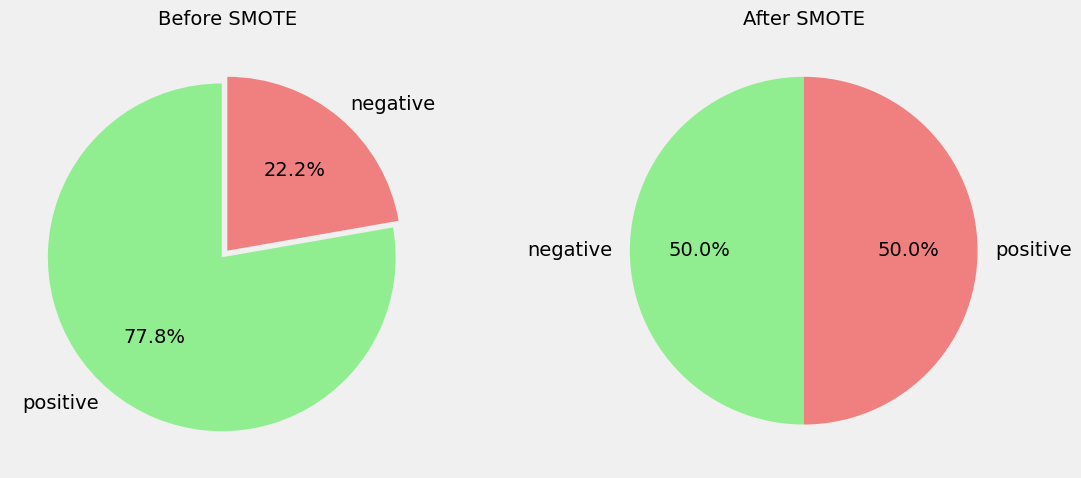

In [225]:

# Visualize class balance before and after SMOTE
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
before_counts = pd.Series(y_train).value_counts()
plt.pie(before_counts.values, labels=before_counts.index, autopct='%1.1f%%',
        colors=['lightgreen', 'lightcoral'], startangle=90, explode=(0.05,0))
plt.title('Before SMOTE', fontsize=14)

plt.subplot(1, 2, 2)
after_counts = pd.Series(y_train_balanced).value_counts()
plt.pie(after_counts.values, labels=after_counts.index, autopct='%1.1f%%',
        colors=['lightgreen', 'lightcoral'], startangle=90)
plt.title('After SMOTE', fontsize=14)

plt.tight_layout()
plt.savefig('smote_comparison.png')
plt.show()

In [226]:
# Step 6: Define models
print("\nDefining ensemble models...")

# Base classifier for bagging
base_clf = DecisionTreeClassifier(max_depth=5, random_state=42)

models = {
    # Bagging ensemble
    'Bagging': BaggingClassifier(
        estimator=base_clf,
        n_estimators=100,
        random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),
    # Boosting ensembles
    'AdaBoost': AdaBoostClassifier(
        estimator=base_clf,
        n_estimators=100,
        random_state=42
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100,
        random_state=42
    ),
    'XGBoost': XGBClassifier(
        n_estimators=100,
        random_state=42,
        eval_metric='logloss'
    ),
    'CatBoost': CatBoostClassifier(
        iterations=100,
        random_state=42,
        verbose=False
    )
}


Defining ensemble models...


In [227]:
# Encoding Labels
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train_balanced)

In [228]:
# Step 7: K-fold cross-validation
print("\nPerforming K-fold cross-validation...")
# Use StratifiedKFold to maintain class balance in each fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = {}
for name, model in models.items():
    start_time = time()
    # We collect all metrics in cross-validation
    accuracy_scores = []
    precision_scores = []
    recall_scores = []
    f1_scores = []

    # Manual cross-validation to get all metrics
    for train_idx, val_idx in skf.split(X_train_balanced, y_train_encoded):
        X_train_fold, X_val_fold = X_train_balanced[train_idx], X_train_balanced[val_idx]
        y_train_fold, y_val_fold = np.array(y_train_encoded)[train_idx], np.array(y_train_balanced)[val_idx]

        model.fit(X_train_fold, y_train_fold)
        y_pred_fold = model.predict(X_val_fold)
        y_pred_fold = le.inverse_transform(y_pred_fold)
        accuracy_scores.append(accuracy_score(y_val_fold, y_pred_fold))
        precision_scores.append(precision_score(y_val_fold, y_pred_fold, pos_label='positive'))
        recall_scores.append(recall_score(y_val_fold, y_pred_fold, pos_label='positive'))
        f1_scores.append(f1_score(y_val_fold, y_pred_fold, pos_label='positive'))

    cv_time = time() - start_time

    cv_results[name] = {
        'accuracy_scores': accuracy_scores,
        'precision_scores': precision_scores,
        'recall_scores': recall_scores,
        'f1_scores': f1_scores,
        'mean_accuracy': np.mean(accuracy_scores),
        'mean_precision': np.mean(precision_scores),
        'mean_recall': np.mean(recall_scores),
        'mean_f1': np.mean(f1_scores),
        'cv_time': cv_time
    }

    print(f"{name:15} - Mean CV Accuracy: {np.mean(accuracy_scores):.4f} (±{np.std(accuracy_scores):.4f}) - Time: {cv_time:.2f}s")



Performing K-fold cross-validation...
Bagging         - Mean CV Accuracy: 0.7733 (±0.0141) - Time: 10.69s
Random Forest   - Mean CV Accuracy: 0.8506 (±0.0343) - Time: 3.34s
AdaBoost        - Mean CV Accuracy: 0.8650 (±0.0364) - Time: 15.70s
Gradient Boosting - Mean CV Accuracy: 0.8295 (±0.0202) - Time: 4.36s
XGBoost         - Mean CV Accuracy: 0.8182 (±0.0304) - Time: 1.84s
CatBoost        - Mean CV Accuracy: 0.8506 (±0.0342) - Time: 10.55s


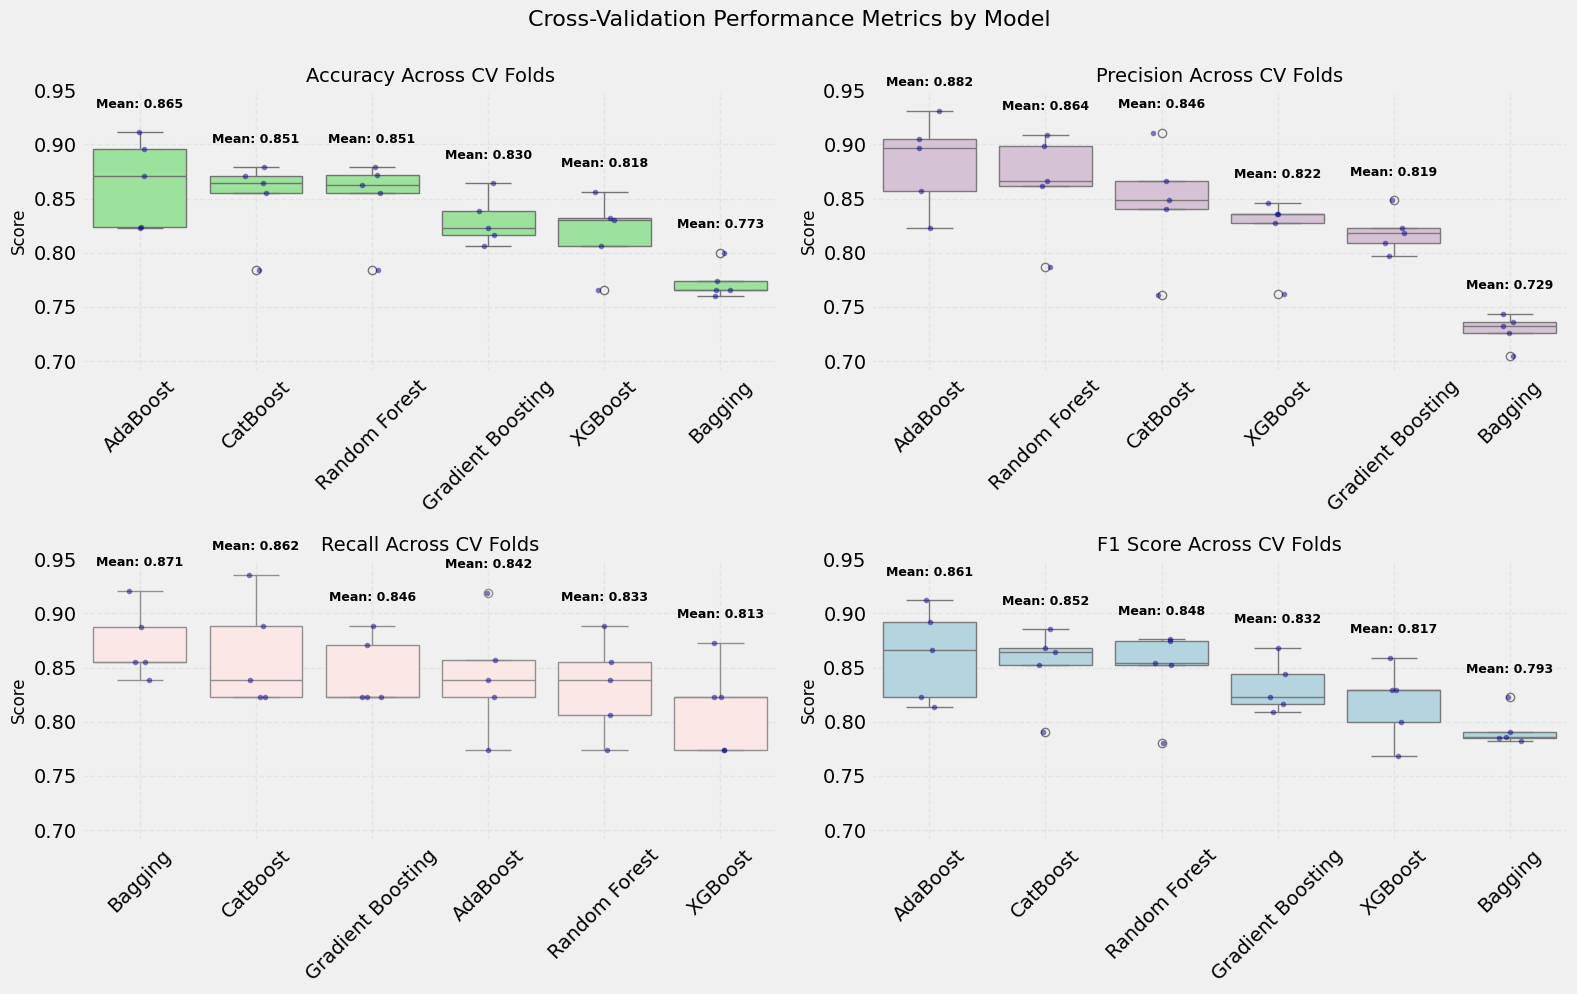

In [250]:
# Create boxplot of cross-validation scores - each metric in a separate subplot
metrics_to_plot = ['accuracy_scores', 'precision_scores', 'recall_scores', 'f1_scores']
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

# Convert to a format suitable for plotting
plot_data = []
for model_name in models.keys():
    for metric_idx, metric in enumerate(metrics_to_plot):
        for score in cv_results[model_name][metric]:
            plot_data.append({
                'Model': model_name,
                'Metric': metric_names[metric_idx],
                'Score': score
            })

# Create DataFrame
plot_df = pd.DataFrame(plot_data)

# Create subplot figure
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

# Colors for boxplots
box_colors = ['lightgreen', 'thistle', 'mistyrose', 'lightblue']

# Create a boxplot for each metric
for i, (metric_name, color) in enumerate(zip(metric_names, box_colors)):
    # Filter data for this metric
    metric_data = plot_df[plot_df['Metric'] == metric_name]

    # Sort models by mean score for this metric
    model_means = metric_data.groupby('Model')['Score'].mean().sort_values(ascending=False)
    model_max = metric_data.groupby('Model')['Score'].max().sort_values(ascending=False)
    sorted_models = model_means.index.tolist()

    # Create boxplot
    ax = axes[i]
    sns.boxplot(x='Model', y='Score', data=metric_data, ax=ax,
                order=sorted_models, color=color)

    # Add individual points
    sns.stripplot(x='Model', y='Score', data=metric_data, ax=ax,
                 order=sorted_models, color='darkblue', alpha=0.5, size=4, jitter=True)

    # Add mean value annotations
    for j, model in enumerate(sorted_models):
        mean_val = model_means[model]
        max_val = model_max[model]
        ax.text(j, max_val + 0.02, f'Mean: {mean_val:.3f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

    ax.set_title(f'{metric_name} Across CV Folds', fontsize=14)
    ax.set_ylim(0.5, 1.05)  # Adjust as needed for your data
    ax.set_xlabel('')
    ax.set_ylabel('Score', fontsize=12)
    ax.tick_params(axis='x', rotation=45)
    ax.set_ylim([0.69,0.95])
    ax.grid(True, linestyle='--', alpha=0.3)

plt.suptitle('Cross-Validation Performance Metrics by Model', fontsize=16, y=0.995)
plt.tight_layout()
plt.savefig('cv_metrics_boxplot.png')
plt.show()



Training final models and evaluating on test set...

--------------------------------------------------
Training and evaluating Bagging...
Accuracy: 0.7500
Precision: 0.8046
Recall: 0.8974
F1 Score: 0.8485
Training time: 1.20 seconds
Prediction time: 0.04 seconds

Classification Report:
              precision    recall  f1-score   support

    negative       0.38      0.23      0.29        22
    positive       0.80      0.90      0.85        78

    accuracy                           0.75       100
   macro avg       0.59      0.56      0.57       100
weighted avg       0.71      0.75      0.72       100



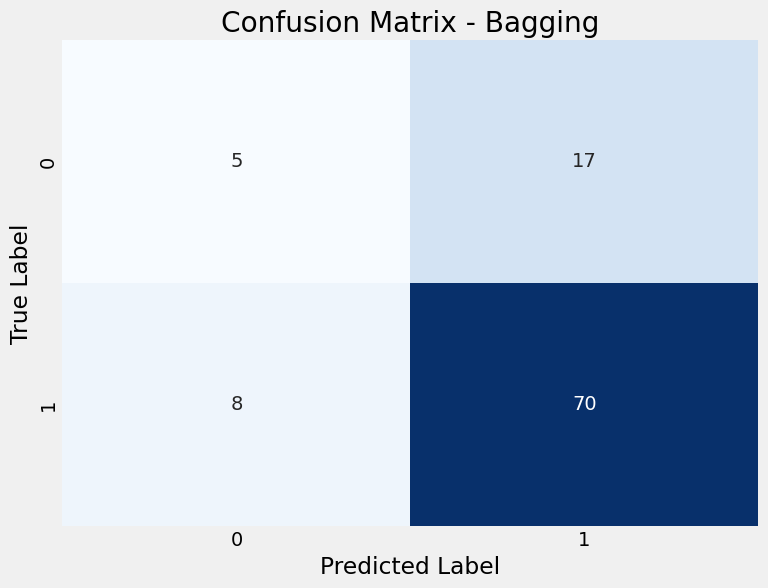


--------------------------------------------------
Training and evaluating Random Forest...
Accuracy: 0.7900
Precision: 0.8353
Recall: 0.9103
F1 Score: 0.8712
Training time: 0.39 seconds
Prediction time: 0.01 seconds

Classification Report:
              precision    recall  f1-score   support

    negative       0.53      0.36      0.43        22
    positive       0.84      0.91      0.87        78

    accuracy                           0.79       100
   macro avg       0.68      0.64      0.65       100
weighted avg       0.77      0.79      0.77       100



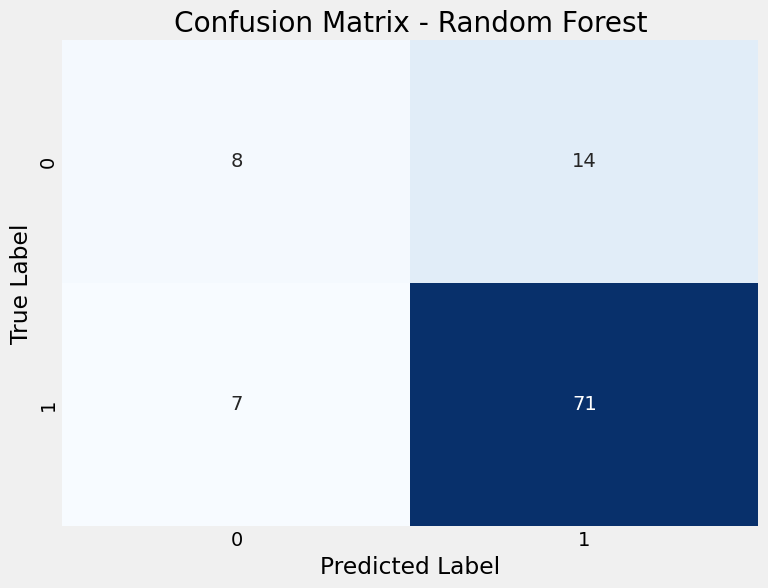


--------------------------------------------------
Training and evaluating AdaBoost...
Accuracy: 0.7400
Precision: 0.8250
Recall: 0.8462
F1 Score: 0.8354
Training time: 1.60 seconds
Prediction time: 0.03 seconds

Classification Report:
              precision    recall  f1-score   support

    negative       0.40      0.36      0.38        22
    positive       0.82      0.85      0.84        78

    accuracy                           0.74       100
   macro avg       0.61      0.60      0.61       100
weighted avg       0.73      0.74      0.74       100



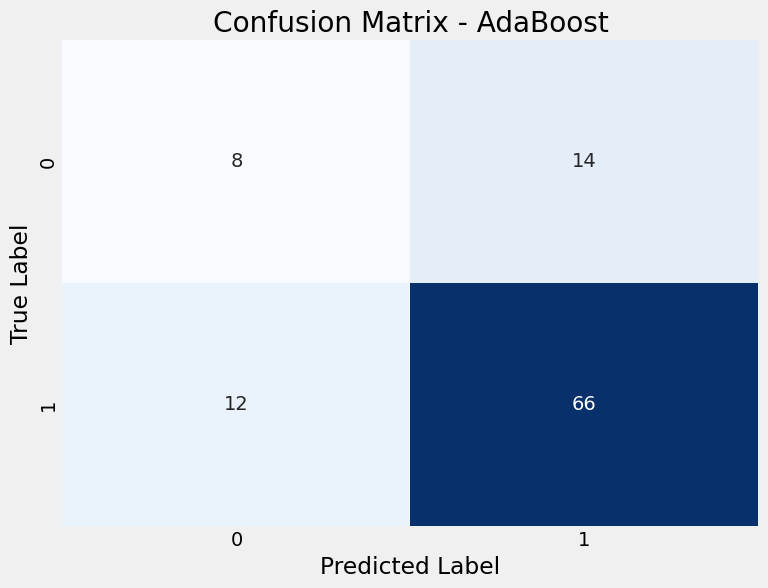


--------------------------------------------------
Training and evaluating Gradient Boosting...
Accuracy: 0.7900
Precision: 0.8353
Recall: 0.9103
F1 Score: 0.8712
Training time: 0.87 seconds
Prediction time: 0.00 seconds

Classification Report:
              precision    recall  f1-score   support

    negative       0.53      0.36      0.43        22
    positive       0.84      0.91      0.87        78

    accuracy                           0.79       100
   macro avg       0.68      0.64      0.65       100
weighted avg       0.77      0.79      0.77       100



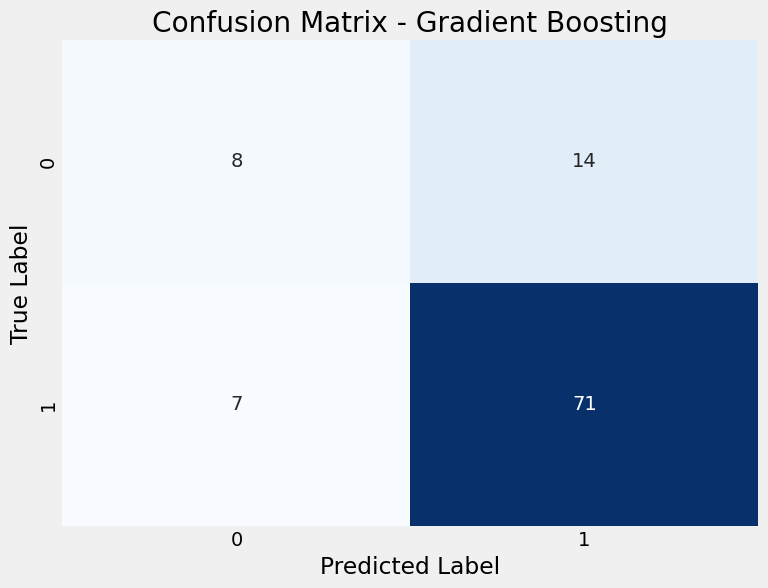


--------------------------------------------------
Training and evaluating XGBoost...
Accuracy: 0.7700
Precision: 0.8313
Recall: 0.8846
F1 Score: 0.8571
Training time: 0.51 seconds
Prediction time: 0.00 seconds

Classification Report:
              precision    recall  f1-score   support

    negative       0.47      0.36      0.41        22
    positive       0.83      0.88      0.86        78

    accuracy                           0.77       100
   macro avg       0.65      0.62      0.63       100
weighted avg       0.75      0.77      0.76       100



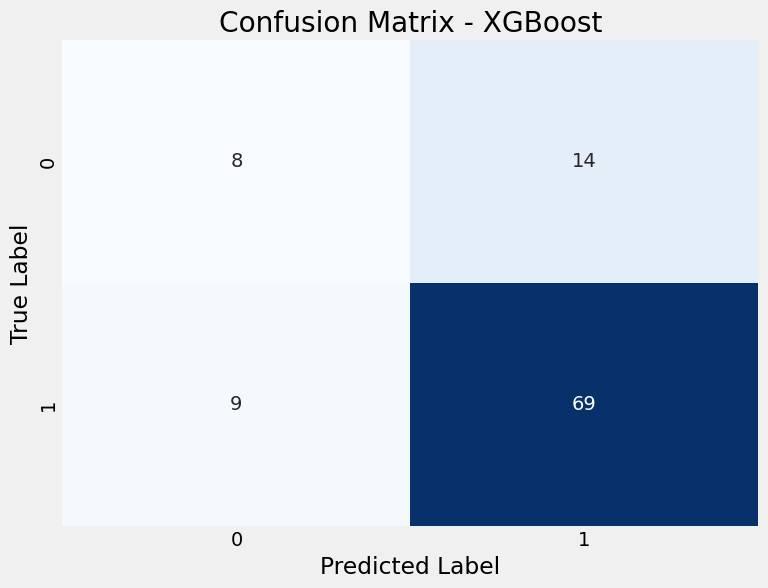


--------------------------------------------------
Training and evaluating CatBoost...
Accuracy: 0.7500
Precision: 0.8046
Recall: 0.8974
F1 Score: 0.8485
Training time: 2.22 seconds
Prediction time: 0.00 seconds

Classification Report:
              precision    recall  f1-score   support

    negative       0.38      0.23      0.29        22
    positive       0.80      0.90      0.85        78

    accuracy                           0.75       100
   macro avg       0.59      0.56      0.57       100
weighted avg       0.71      0.75      0.72       100



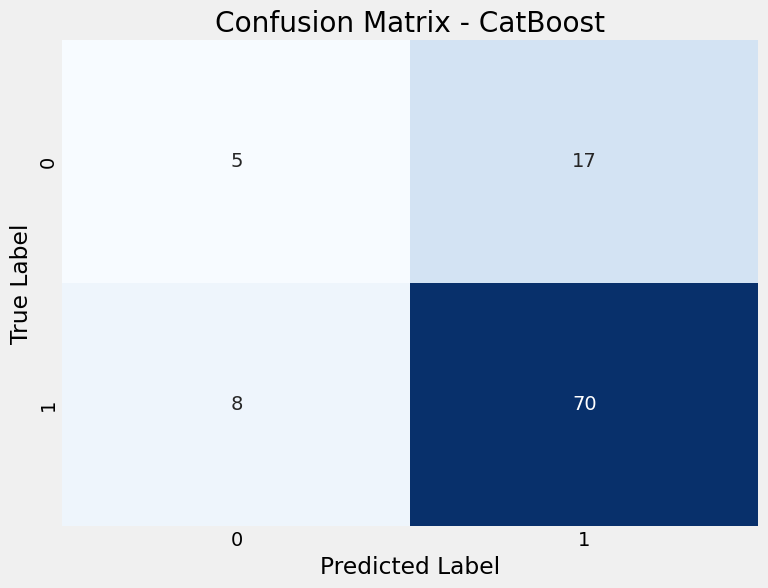

In [230]:
# Step 8: Train final models and evaluate on test set
print("\nTraining final models and evaluating on test set...")

results = {}
for name, model in models.items():
    print(f"\n{'-'*50}")
    print(f"Training and evaluating {name}...")

    # Train model
    start_time = time()
    model.fit(X_train_balanced, y_train_encoded)
    train_time = time() - start_time

    # Make predictions
    start_time = time()
    y_pred = le.inverse_transform(model.predict(X_test_tfidf))
    predict_time = time() - start_time

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, pos_label='positive')
    recall = recall_score(y_test, y_pred, pos_label='positive')
    f1 = f1_score(y_test, y_pred, pos_label='positive')

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"Training time: {train_time:.2f} seconds")
    print(f"Prediction time: {predict_time:.2f} seconds")

    # Classification report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'Confusion Matrix - {name}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.savefig(f'confusion_matrix_{name.replace(" ", "_")}.png')
    plt.show()

    # Store results
    results[name] = {
        'model': model,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'train_time': train_time,
        'predict_time': predict_time
    }

In [252]:
# Step 9: Compare models
print("\nComparing model performance...")

# Create DataFrame for comparison
results_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [results[model]['accuracy'] for model in results],
    'Precision': [results[model]['precision'] for model in results],
    'Recall': [results[model]['recall'] for model in results],
    'F1 Score': [results[model]['f1'] for model in results]
})

print(results_df.sort_values('F1 Score', ascending=False))



Comparing model performance...
               Model  Accuracy  Precision    Recall  F1 Score
1      Random Forest      0.79   0.835294  0.910256  0.871166
3  Gradient Boosting      0.79   0.835294  0.910256  0.871166
4            XGBoost      0.77   0.831325  0.884615  0.857143
0            Bagging      0.75   0.804598  0.897436  0.848485
5           CatBoost      0.75   0.804598  0.897436  0.848485
2           AdaBoost      0.74   0.825000  0.846154  0.835443


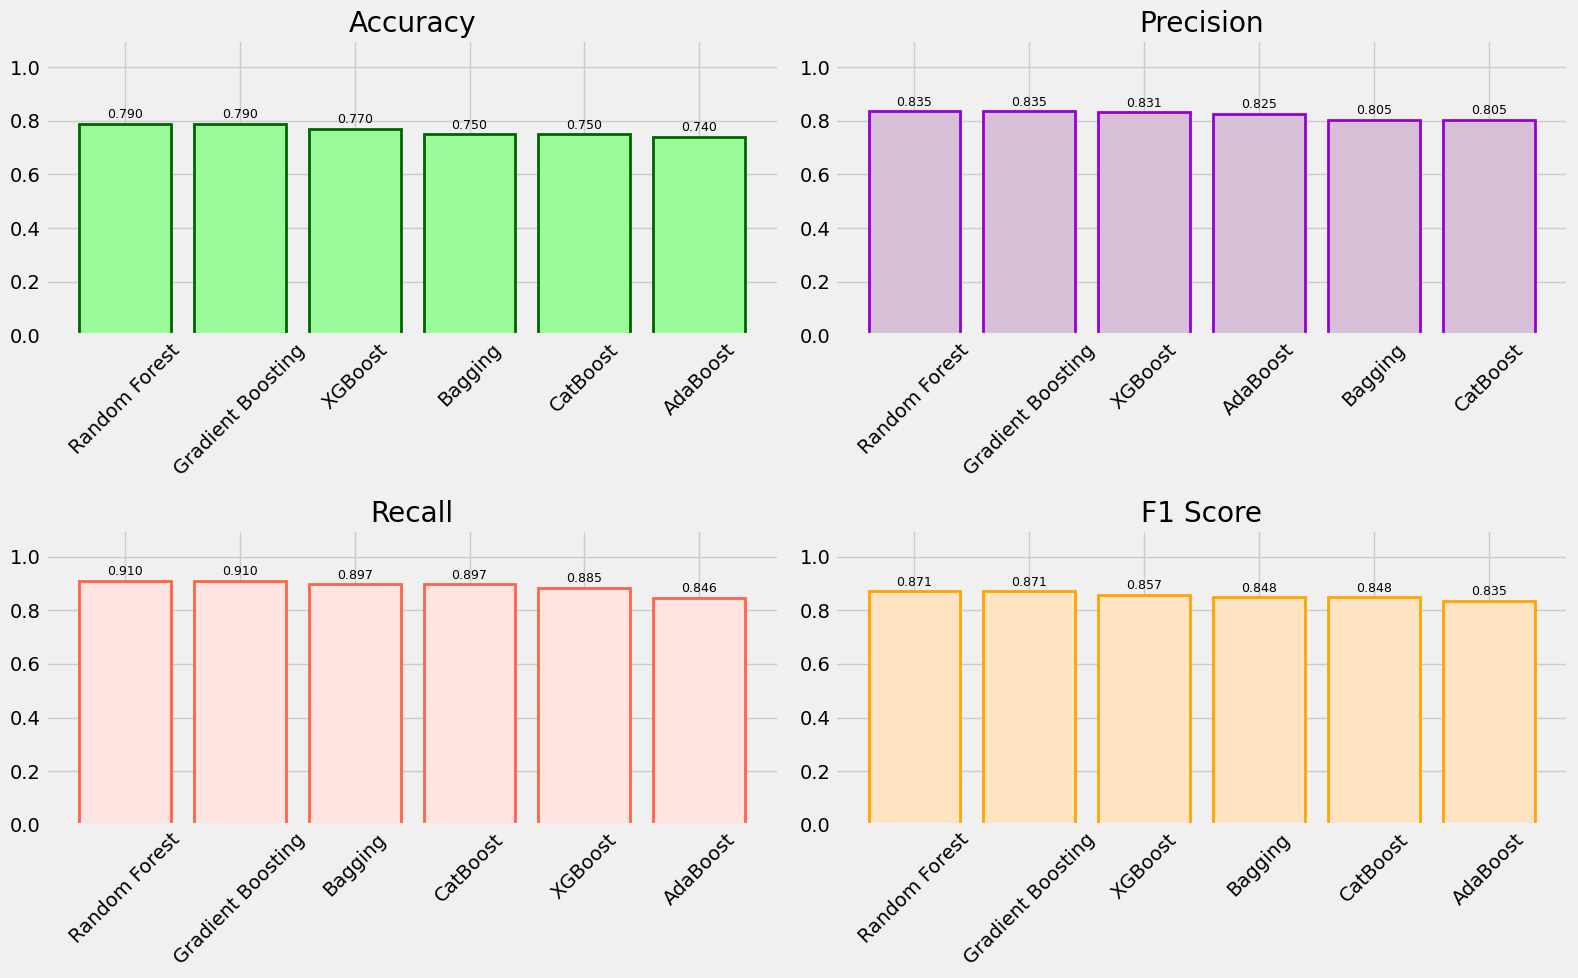

In [253]:

# Visualize comparison with bar charts
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

colors = [('palegreen', 'darkgreen'), ('thistle', 'darkviolet'),
          ('mistyrose', 'tomato'), ('bisque', 'orange')]

for i, (metric, color) in enumerate(zip(metrics, colors)):
    ax = axes[i]
    results_df_sorted = results_df.sort_values(metric, ascending=False)
    bars = ax.bar(results_df_sorted['Model'], results_df_sorted[metric],
                  color=color[0], edgecolor=color[1], linewidth=2)

    # Add value labels on top of bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

    ax.set_title(metric)
    ax.set_ylim(0, 1.1)  # Set y-axis limit
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('model_comparison_bar.png')
plt.show()

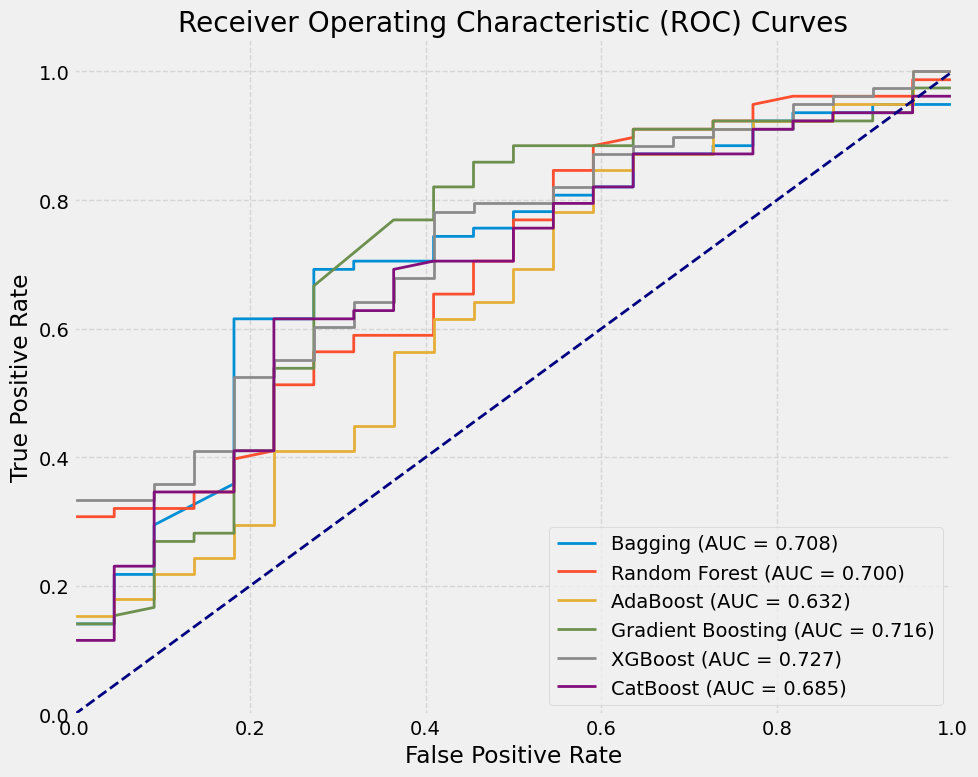

In [254]:
# Step 10: ROC curves for models
plt.figure(figsize=(10, 8))

for name, result in results.items():
    model = result['model']

    # Get probability predictions for positive class
    if hasattr(model, 'predict_proba'):
        # Get the index for the positive class
        classes = le.inverse_transform(model.classes_)
        positive_idx = np.where(classes == 'positive')[0][0]
        y_prob = model.predict_proba(X_test_tfidf)[:, positive_idx]
    else:
        # For models that don't have predict_proba
        # For simplicity, we'll skip these models
        print(f"Skipping ROC curve for {name} as it doesn't support predict_proba")
        continue

    # Compute ROC curve and AUC
    label_encoder = LabelEncoder().fit(['negative', 'positive'])
    y_test_encoded = label_encoder.transform(y_test)

    fpr, tpr, _ = roc_curve(y_test_encoded, y_prob)
    roc_auc = auc(fpr, tpr)

    # Plot ROC curve
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curves')
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('roc_curves.png')
plt.show()




Best model: Random Forest with F1 Score: 0.8712


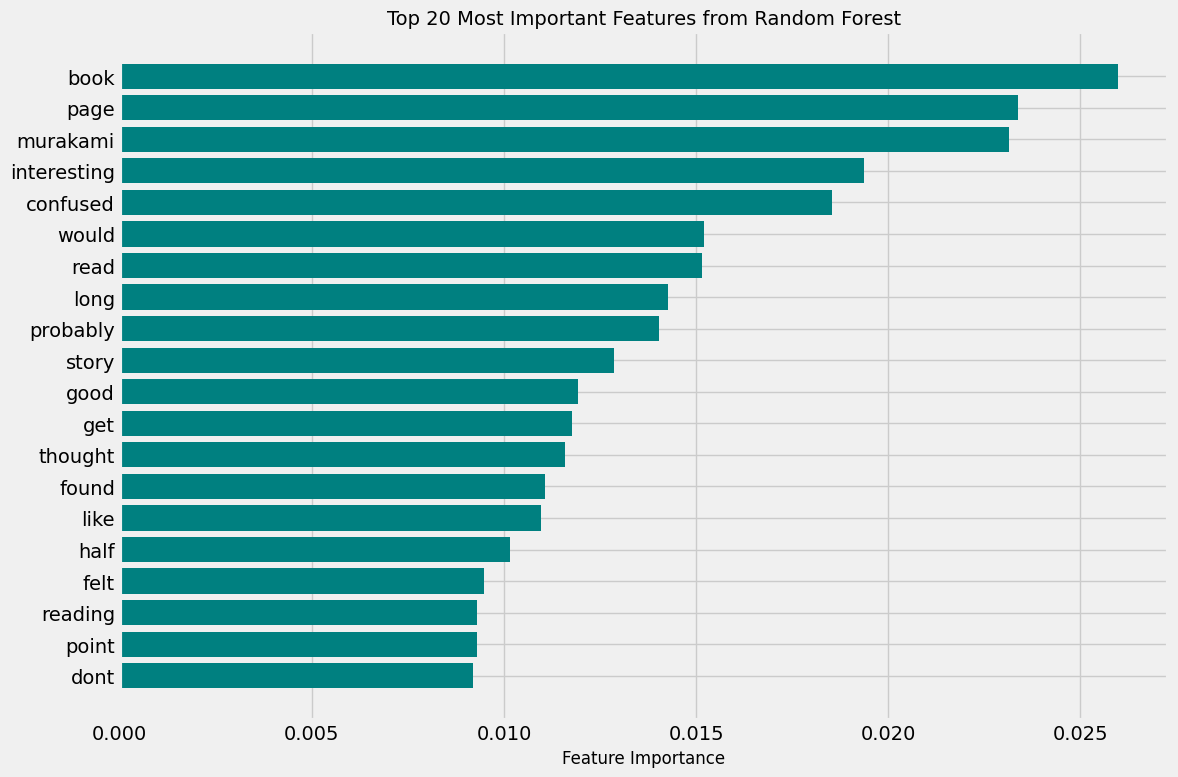


Top 10 most important features from Random Forest:
         Feature  Importance
44          book    0.025985
359         page    0.023380
324     murakami    0.023148
234  interesting    0.019359
76      confused    0.018539
564        would    0.015214
391         read    0.015156
279         long    0.014267
378     probably    0.014029
463        story    0.012862


In [255]:
# Step 11: Feature importance for the best model
best_model_name = results_df.sort_values('F1 Score', ascending=False).iloc[0]['Model']
best_model = results[best_model_name]['model']

print(f"\nBest model: {best_model_name} with F1 Score: {results[best_model_name]['f1']:.4f}")

# For tree-based models, extract feature importance
if hasattr(best_model, 'feature_importances_'):
    # If it's a bagging or boosting ensemble with base estimators
    if hasattr(best_model, 'estimators_'):
        feature_importances = np.mean([tree.feature_importances_
                                      for tree in best_model.estimators_], axis=0)
    else:
        feature_importances = best_model.feature_importances_

    # Get feature names
    feature_names = tfidf_vectorizer.get_feature_names_out()

    # Create a DataFrame for easier handling
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': feature_importances
    }).sort_values('Importance', ascending=False)

    # Plot top features
    top_n = 20
    plt.figure(figsize=(12, 8))
    plt.barh(importance_df['Feature'][:top_n][::-1], importance_df['Importance'][:top_n][::-1], color='teal')
    plt.title(f'Top {top_n} Most Important Features from {best_model_name}', fontsize=14)
    plt.xlabel('Feature Importance', fontsize=12)
    plt.tight_layout()
    plt.savefig('feature_importance.png')
    plt.show()

    print(f"\nTop 10 most important features from {best_model_name}:")
    print(importance_df.head(10))



In [257]:
# Step 12: Sample predictions
print("\nSample predictions from the best model:")

# Get a few sample reviews, intentionally selecting some where the model might be wrong
# First, get predictions for all test samples
all_test_preds = le.inverse_transform(best_model.predict(X_test_tfidf))

# Find indices where predictions were incorrect
incorrect_indices = np.where(all_test_preds != y_test)[0]

# Select a few random incorrect predictions and a few correct ones
num_samples = 5
if len(incorrect_indices) > 0:
    # Select some incorrect predictions
    num_incorrect = min(2, len(incorrect_indices))
    incorrect_samples = np.random.choice(incorrect_indices, num_incorrect, replace=False)

    # Select remaining samples from correct predictions
    correct_indices = np.where(all_test_preds == y_test)[0]
    correct_samples = np.random.choice(correct_indices, num_samples - num_incorrect, replace=False)

    # Combine them
    sample_indices = np.concatenate([incorrect_samples, correct_samples])
else:
    # If all predictions are correct, just select random samples
    sample_indices = np.random.choice(len(X_test), num_samples, replace=False)

# Get the selected reviews
sample_reviews = X_test.iloc[sample_indices].values
sample_actual = y_test.iloc[sample_indices].values
sample_reviews_tfidf = tfidf_vectorizer.transform(sample_reviews)
sample_preds = best_model.predict(sample_reviews_tfidf)

# Display results
for i, (review, actual, pred) in enumerate(zip(sample_reviews, sample_actual, sample_preds)):
    correct = actual == pred
    print(f"\nSample {i+1}:")
    print(f"Review: {review[:100]}..." if len(review) > 100 else f"Review: {review}")
    print(f"Actual sentiment: {actual}")
    print(f"Predicted sentiment: {pred}")
    print(f"Correct: {'✓' if correct else '✗'}")

# Step 13: Summary
print("\nSummary:")
print(f"The {best_model_name} model performed best with:")
print(f"- F1 Score: {results[best_model_name]['f1']:.4f}")
print(f"- Accuracy: {results[best_model_name]['accuracy']:.4f}")
print(f"- Precision: {results[best_model_name]['precision']:.4f}")
print(f"- Recall: {results[best_model_name]['recall']:.4f}")

# Summarize class distribution and balancing
print("\nDataset information:")
print(f"- Total reviews: {len(df)}")
print(f"- Original class distribution: Positive {sentiment_percent['positive']:.1f}%, Negative {sentiment_percent['negative']:.1f}%")
print("- Used SMOTE to balance classes during training")

print("\nRecommendations:")
print("1. Consider using the best model for sentiment analysis of new reviews")
print("2. The feature importance analysis can provide insights into what words or phrases are most indicative of positive/negative sentiment")
print("3. For deployment, consider creating a simple API or web interface for real-time sentiment predictions")
print("4. Consider expanding the model to predict the actual star rating (1-5) instead of just binary sentiment")


Sample predictions from the best model:

Sample 1:
Review: interesting story
Actual sentiment: positive
Predicted sentiment: 0
Correct: ✗

Sample 2:
Review: sure enjoyed felt compelled keep reading different book ever read
Actual sentiment: negative
Predicted sentiment: 1
Correct: ✗

Sample 3:
Review: one best novel ever read
Actual sentiment: positive
Predicted sentiment: 1
Correct: ✗

Sample 4:
Review: murakami incredible beautiful piece literature
Actual sentiment: positive
Predicted sentiment: 1
Correct: ✗

Sample 5:
Review: would recommend novel anyone personally love curling enjoy metaphysical subject matter presented rea...
Actual sentiment: positive
Predicted sentiment: 1
Correct: ✗

Summary:
The Random Forest model performed best with:
- F1 Score: 0.8712
- Accuracy: 0.7900
- Precision: 0.8353
- Recall: 0.9103

Dataset information:
- Total reviews: 500
- Original class distribution: Positive 77.8%, Negative 22.2%
- Used SMOTE to balance classes during training

Recommendations

In [263]:
print("Training and saving models...")
for name, model in models.items():
    with open(f'/content/models/{name.lower().replace(" ", "_")}_model.pkl', 'wb') as f:
        pickle.dump(model, f)
    print(f"Saved {name} model")

# Save the vectorizer
print("Saving TF-IDF vectorizer...")
with open('/content/models/tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf_vectorizer, f)

# Save the label encoder
print("Saving label encoder...")
with open('/content/models/label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

Training and saving models...
Saved Bagging model
Saved Random Forest model
Saved AdaBoost model
Saved Gradient Boosting model
Saved XGBoost model
Saved CatBoost model
Saving TF-IDF vectorizer...
Saving label encoder...
